In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"D:\PythonProject1\Intern\Images\img75.jpeg"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(cv2.GaussianBlur(gray, (3, 3), 0), 200, 255, cv2.THRESH_BINARY)
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)))
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

pieces, masks, boundaries = [], [], []
for c in [cnt for cnt in contours if cv2.contourArea(cnt) > 500]:
    x, y, w, h = cv2.boundingRect(c)
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [c], -1, 255, -1)
    cropped_mask = mask[y:y+h, x:x+w]
    
    boundary = cv2.absdiff(cv2.dilate(cropped_mask, np.ones((3,3), np.uint8)), cropped_mask)
    pieces.append(cv2.bitwise_and(image[y:y+h, x:x+w], image[y:y+h, x:x+w], mask=cropped_mask))
    masks.append(cropped_mask)
    boundaries.append(boundary)

num_pieces = len(pieces)

def find_best_translation(i, j):
    bi, bj, mi, mj = boundaries[i], boundaries[j], masks[i], masks[j]
    hi, wi = bi.shape
    hj, wj = bj.shape
    
    padded_b = cv2.copyMakeBorder(bi, hj, hj, wj, wj, cv2.BORDER_CONSTANT, value=0)
    corr = cv2.matchTemplate(padded_b, bj, cv2.TM_CCORR)
    flat_indices = np.argsort(corr.ravel())[-150:][::-1]
    
    best_score, best_dx, best_dy = -1, 0, 0
    for idx in flat_indices:
        r, c = np.unravel_index(idx, corr.shape)
        dx, dy = c - wj, r - hj
        
        y_start_i, y_end_i = max(0, dy), min(hi, dy + hj)
        x_start_i, x_end_i = max(0, dx), min(wi, dx + wj)
        y_start_j, y_end_j = max(0, -dy), min(hj, hi - dy)
        x_start_j, x_end_j = max(0, -dx), min(wj, wi - dx)
        
        if (y_end_i <= y_start_i) or (x_end_i <= x_start_i):
            continue
            
        if np.sum((mi[y_start_i:y_end_i, x_start_i:x_end_i] > 0) & (mj[y_start_j:y_end_j, x_start_j:x_end_j] > 0)) > (0.015 * min(np.sum(mi > 0), np.sum(mj > 0))):
            continue
            
        contact_score = np.sum((bi[y_start_i:y_end_i, x_start_i:x_end_i] > 0) & (bj[y_start_j:y_end_j, x_start_j:x_end_j] > 0))
        if contact_score > best_score:
            best_score, best_dx, best_dy = contact_score, dx, dy
            
    return best_dx, best_dy, best_score

match_graph = []
for i in range(num_pieces):
    for j in range(i + 1, num_pieces):
        dx, dy, score = find_best_translation(i, j)
        if score > 5:
            match_graph.append({'i': i, 'j': j, 'dx': dx, 'dy': dy, 'score': score})
match_graph.sort(key=lambda x: x['score'], reverse=True)

positions = {np.argmax([np.sum(m > 0) for m in masks]): (0, 0)}
placed = set(positions.keys())

while len(placed) < num_pieces:
    progress = False
    for match in match_graph:
        i, j, dx, dy = match['i'], match['j'], match['dx'], match['dy']
        if i in placed and j not in placed:
            positions[j] = (positions[i][0] + dx, positions[i][1] + dy)
            placed.add(j)
            progress = True
            break
        elif j in placed and i not in placed:
            positions[i] = (positions[j][0] - dx, positions[j][1] - dy)
            placed.add(i)
            progress = True
            break
    if not progress:
        fallback = list(set(range(num_pieces)) - placed)[0]
        positions[fallback] = (0, 0)
        placed.add(fallback)

min_x = min(pos[0] for pos in positions.values())
min_y = min(pos[1] for pos in positions.values())
norm_pos = {k: (pos[0] - min_x, pos[1] - min_y) for k, pos in positions.items()}

max_w = max(px + pieces[idx].shape[1] for idx, (px, py) in norm_pos.items())
max_h = max(py + pieces[idx].shape[0] for idx, (px, py) in norm_pos.items())
canvas = np.zeros((max_h, max_w, 3), dtype=np.uint8)

for idx, (px, py) in norm_pos.items():
    img, m = pieces[idx], masks[idx]
    canvas[py:py+img.shape[0], px:px+img.shape[1]][m > 0] = img[m > 0]

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


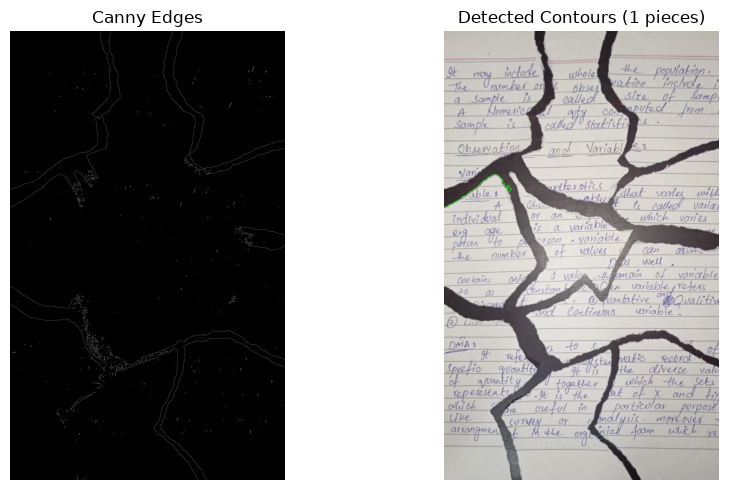

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = r"D:\PythonProject1\Intern\Images\img75.jpeg"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

# Step 1: Smooth out texture and ink noise
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Step 2: Convert to HSV to separate paper color from dark background cracks
hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
lower_paper = np.array([0, 0, 80])
upper_paper = np.array([180, 75, 255])
paper_mask = cv2.inRange(hsv, lower_paper, upper_paper)

# Step 3: Morphological opening to cut thin bridges between pieces
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
separated_mask = cv2.morphologyEx(paper_mask, cv2.MORPH_OPEN, kernel)

# Step 4: Apply Canny Edge Detection on the isolated paper mask
# Since it's a binary mask, thresholds of 50 and 150 will yield clean boundaries
edges = cv2.Canny(separated_mask, 50, 150)

# Step 5: Find contours from the Canny edges
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 6: Filter out small noise pieces
valid_contours = [c for c in contours if cv2.contourArea(c) > 500]

# --- VISUALIZATION OF CANNY EDGES & CONTOURS ---
plt.figure(figsize=(10, 5))

# Plot Canny Output
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')

# Plot Contours drawn on Original Image
plt.subplot(1, 2, 2)
contour_vis = image.copy()
cv2.drawContours(contour_vis, valid_contours, -1, (0, 255, 0), 3)
plt.imshow(cv2.cvtColor(contour_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Contours ({len(valid_contours)} pieces)")
plt.axis('off')

plt.tight_layout()
plt.show()